# Master Data Preparation Pipeline
**Project:** Jivara (CC26-PSU090) - Sistem Deteksi Interaksi Obat-Makanan  
**Role:** Data Science (Rizki Pangestu)

Pipeline ini memproses dataset mentah menjadi artefak siap pakai untuk AI Engineer dan Backend Developer.

## Pertanyaan Bisnis

1. **Bagaimana profil nutrisi 61 kelas makanan target model AI?** Seluruh lookup nutrisi difokuskan pada dataset `nutrition1.csv` dan kelas dari `61_kelas_resep_cleaned.csv`.
2. **Bagaimana profil dan distribusi obat-obatan yang terdaftar di BPOM?** Bagaimana distribusi golongan obat, top perusahaan farmasi, bentuk sediaan, tren registrasi, dan komposisi zat aktifnya?
3. **Apakah 61 kelas makanan target model AI sudah memiliki data nutrisi yang lengkap?** Berapa banyak kelas yang datanya hilang dari `nutrition1.csv` dan perlu diimputasi secara manual?
4. **Seberapa siap dataset untuk digunakan oleh AI Engineer?** Apakah seluruh pemetaan antara output model (class name) dan database nutrisi sudah terverifikasi?


---
## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import os
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

BASE_DIR = Path(r'..')
RAW_DIR = BASE_DIR / 'data_mentah'
OUTPUT_DIR = BASE_DIR / 'data_output'

for subdirectory in ['processed', 'for_backend', 'docs', 'for_ai_engineer']:
    (OUTPUT_DIR / subdirectory).mkdir(parents=True, exist_ok=True)

print("Library dan direktori siap.")

Library dan direktori siap.


---
## 2. Data Wrangling — Dataset 1: Nutrisi Makanan Indonesia (`nutrition1.csv`)

### 2.1 Gathering Data

In [2]:
nutrition_indo_raw = pd.read_csv(RAW_DIR / 'nutrition1.csv')
print(f"Shape: {nutrition_indo_raw.shape}")
nutrition_indo_raw.head()

Shape: (1346, 7)


,id,calories,proteins,fat,carbohydrate,name,image
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...


### 2.2 Assessing Data

In [3]:
print("--- Info ---")
print(nutrition_indo_raw.dtypes)
print(f"\n--- Missing Values ---")
print(nutrition_indo_raw.isnull().sum())
print(f"\n--- Duplikasi Nama ---")
print(f"Nama duplikat: {nutrition_indo_raw['name'].duplicated().sum()}")
print(f"\n--- Statistik Deskriptif ---")
nutrition_indo_raw.describe()

--- Info ---
id                int64
calories        float64
proteins        float64
fat             float64
carbohydrate    float64
name             object
image            object
dtype: object

--- Missing Values ---
id              0
calories        0
proteins        0
fat             0
carbohydrate    0
name            0
image           0
dtype: int64

--- Duplikasi Nama ---
Nama duplikat: 0

--- Statistik Deskriptif ---


,id,calories,proteins,fat,carbohydrate
count,1346.000000,1346.000000,1346.000000,1346.000000,1346.000000
mean,673.500000,203.217385,10.001189,7.584027,25.390193
std,388.701042,163.075430,11.847980,13.733063,32.193054
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,337.250000,75.000000,1.800000,0.500000,4.525000
50%,673.500000,146.000000,5.000000,2.000000,13.300000
75%,1009.750000,333.750000,15.000000,8.275000,37.575000
max,1346.000000,940.000000,83.000000,100.000000,647.000000


### 2.3 Cleaning Data

Langkah pembersihan:
- Hapus kolom metadata yang tidak dibutuhkan (`id`, `image`)
- Standarisasi nama kolom (rename `name` menjadi `food_name`)
- Hapus whitespace trailing pada nama makanan
- Hapus baris duplikat berdasarkan `food_name`

In [4]:
nutrition_indo = nutrition_indo_raw.copy()

# Hapus kolom yang tidak dibutuhkan untuk analisis nutrisi
columns_to_drop = [col for col in ['id', 'image'] if col in nutrition_indo.columns]
nutrition_indo.drop(columns=columns_to_drop, inplace=True)

# Standarisasi nama kolom
nutrition_indo.rename(columns={'name': 'food_name'}, inplace=True)

# Bersihkan whitespace
nutrition_indo['food_name'] = nutrition_indo['food_name'].str.strip()

# Hapus duplikat
before_dedup = len(nutrition_indo)
nutrition_indo.drop_duplicates(subset=['food_name'], inplace=True)
after_dedup = len(nutrition_indo)

# Tambahkan kolom sumber data
nutrition_indo['source'] = 'nutrition1_indonesia'
nutrition_indo['weight_grams'] = 100.0

print(f"Baris dihapus (duplikat): {before_dedup - after_dedup}")
print(f"Shape final: {nutrition_indo.shape}")
nutrition_indo.head()

Baris dihapus (duplikat): 0
Shape final: (1346, 7)


,calories,proteins,fat,carbohydrate,food_name,source,weight_grams
0,280.0,9.2,28.4,0.0,Abon,nutrition1_indonesia,100.0
1,513.0,23.7,37.0,21.3,Abon haruwan,nutrition1_indonesia,100.0
2,0.0,0.0,0.2,0.0,Agar-agar,nutrition1_indonesia,100.0
3,45.0,1.1,0.4,10.8,Akar tonjong segar,nutrition1_indonesia,100.0
4,37.0,4.4,0.5,3.8,Aletoge segar,nutrition1_indonesia,100.0


---
## 3. Fokus Database Nutrisi 61 Kelas

Bagian ini tidak lagi menggabungkan dataset nutrisi global. Database nutrisi dibuat dari `nutrition1.csv`, lalu dipersempit ke 61 kelas makanan target dari `61_kelas_resep_cleaned.csv`.


In [ ]:
# Tambahkan kolom yang hilang agar schema seragam
nutrition_indo['food_name_en'] = np.nan
for extra_col in ['fiber', 'sugars', 'sodium']:
    if extra_col not in nutrition_indo.columns:
        nutrition_indo[extra_col] = np.nan

TARGET_COLUMNS = ['food_name', 'food_name_en', 'source', 'calories',
                  'proteins', 'fat', 'carbohydrate', 'weight_grams',
                  'fiber', 'sugars', 'sodium']

nutrition_reference = nutrition_indo[TARGET_COLUMNS].copy()
nutrition_reference['food_name'] = nutrition_reference['food_name'].str.strip()

# Ambil 61 kelas target dari dataset resep yang sudah dibersihkan.
recipe_classes_path = OUTPUT_DIR / 'processed' / '61_kelas_resep_cleaned.csv'
recipe_classes = pd.read_csv(recipe_classes_path)
target_food_classes = sorted(recipe_classes['Kelas_YOLO'].dropna().unique())

if len(target_food_classes) != 61:
    raise ValueError(f"Expected 61 target classes, got {len(target_food_classes)}")

print(f"Referensi nutrisi dari nutrition1.csv: {len(nutrition_reference)} entri")
print(f"Target kelas makanan: {len(target_food_classes)} kelas")
print(target_food_classes[:10])


---
## 4. Data Wrangling — Dataset 3: Data Registrasi Obat BPOM (`obat_bpom_all_data.csv`)

### 4.1 Gathering Data


In [9]:
obat_bpom_raw = pd.read_csv(RAW_DIR / 'obat_bpom_all_data.csv')
print(f"Shape: {obat_bpom_raw.shape}")
obat_bpom_raw.head()


Shape: (23682, 11)


,No,Nomor Registrasi,Nama Produk,Merk,Komposisi,Bentuk Sediaan,Kemasan,Pendaftar,Tanggal Terbit,Masa Berlaku s/d,Status
0,1,DTL1840403510A1,DIMETIC,-,DIMENHYDRINATE,TABLET,"DUS, 2 BLISTER @ 10 TABLET",PRIMA MEDIKA LABORATORIES - Indonesia,2026-05-05,2027-05-31,Berlaku
1,2,DKL1415715709A1,AZTERCON,-,AZITHROMYCIN DIHYDRATE,KAPLET SALUT SELAPUT,"DUS, 10 BLISTER @ 3 KAPLET SALUT SELAPUT",ETERCON PHARMA - Indonesia,2026-05-05,2031-05-05,Berlaku
2,3,DBL8305501304A1,DUMIN,-,PARACETAMOL,KAPLET,"DUS, 10 BLISTER @ 10 KAPLET",ACTAVIS INDONESIA - Indonesia,2026-05-05,2031-05-05,Berlaku
3,4,GKL2632724717B1,LEVETIRACETAM,-,LEVETIRACETAM,TABLET SALUT SELAPUT,"DUS, 3 BLISTER @ 10 TABLET SALUT SELAPUT",YARINDO FARMATAMA - Indonesia,2026-05-05,2031-05-05,Berlaku
4,5,DKL2128209617B1,MAXLIS 20,-,TADALAFIL,TABLET SALUT SELAPUT,"DUS, 1 STRIP @ 4 TABLET SALUT SELAPUT",SIMEX PHARMACEUTICAL INDONESIA - Indonesia,2026-05-05,2031-03-23,Berlaku


### 4.2 Assessing Data


In [10]:
print("--- Info ---")
print(obat_bpom_raw.dtypes)
print(f"\n--- Missing Values ---")
print(obat_bpom_raw.isnull().sum())
print(f"\n--- Duplikasi Nomor Registrasi ---")
dup_reg = obat_bpom_raw['Nomor Registrasi'].value_counts()
print(f"Nomor Registrasi duplikat (beda kemasan): {(dup_reg > 1).sum()}")
print(f"\n--- Statistik Deskriptif ---")
obat_bpom_raw.describe(include='all')


--- Info ---
No                   int64
Nomor Registrasi    object
Nama Produk         object
Merk                object
Komposisi           object
Bentuk Sediaan      object
Kemasan             object
Pendaftar           object
Tanggal Terbit      object
Masa Berlaku s/d    object
Status              object
dtype: object

--- Missing Values ---
No                     0
Nomor Registrasi       0
Nama Produk            0
Merk                   0
Komposisi           4346
Bentuk Sediaan         0
Kemasan                0
Pendaftar              0
Tanggal Terbit         0
Masa Berlaku s/d       0
Status                 0
dtype: int64

--- Duplikasi Nomor Registrasi ---
Nomor Registrasi duplikat (beda kemasan): 6001

--- Statistik Deskriptif ---


,No,Nomor Registrasi,Nama Produk,Merk,Komposisi,Bentuk Sediaan,Kemasan,Pendaftar,Tanggal Terbit,Masa Berlaku s/d,Status
count,23682.000000,23682,23682,23682,19336,23682,23682,23682,23682,23682,23682
unique,NaN,15085,9167,1,2477,4975,3164,208,1348,1915,2
top,NaN,LKE20066191,AMLODIPINE BESILATE,-,PARACETAMOL,TABLET,"DUS, 1 BOTOL @ 60 ML",DEXA MEDICA - Indonesia,2025-12-31,2025-08-23,Berlaku
freq,NaN,19,169,23682,574,1980,1183,817,123,464,23105
mean,11841.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,6836.548874,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,5921.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,11841.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,17761.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4.3 Cleaning Data

Langkah pembersihan:
- Hapus kolom `No` dan `Merk` (tidak memberikan informasi berguna)
- Pembersihan entitas HTML (seperti `&lt;br&gt;`) pada kolom `Komposisi` dan `Nama Produk`
- Parse `Pendaftar` menjadi `Perusahaan` dan `Negara_Asal`
- Ekstrak Kategori, Golongan, dan Asal Obat berdasarkan prefix `Nomor Registrasi`
- Parse `Komposisi` menjadi daftar (list) zat aktif
- Hitung durasi registrasi obat dalam tahun
- Identifikasi status kedaluwarsa obat berdasarkan `Masa Berlaku s/d`
- Lakukan deduplikasi baris untuk menggabungkan varian kemasan ke dalam satu baris per produk unik


In [11]:
import html

obat_bpom = obat_bpom_raw.copy()

# 1. Hapus kolom yang tidak berguna
cols_to_drop = ['No', 'Merk']
obat_bpom.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# 2. Bersihkan HTML entities
def clean_html_text(text):
    if pd.isna(text):
        return text
    text = html.unescape(text)
    text = re.sub(r'<br\s*/?>', ' | ', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

obat_bpom['Komposisi'] = obat_bpom['Komposisi'].apply(clean_html_text)
obat_bpom['Nama Produk'] = obat_bpom['Nama Produk'].apply(lambda x: html.unescape(x).strip() if pd.notna(x) else x)

# 3. Konversi tipe data tanggal
obat_bpom['Tanggal Terbit'] = pd.to_datetime(obat_bpom['Tanggal Terbit'], errors='coerce')
obat_bpom['Masa Berlaku s/d'] = pd.to_datetime(obat_bpom['Masa Berlaku s/d'], errors='coerce')

# 4. Parse pendaftar (Perusahaan & Negara Asal)
def parse_pendaftar(text):
    if pd.isna(text): return text, None
    parts = text.rsplit(' - ', 1)
    return (parts[0].strip(), parts[1].strip()) if len(parts) == 2 else (text.strip(), None)

obat_bpom[['Perusahaan', 'Negara_Asal']] = obat_bpom['Pendaftar'].apply(lambda x: pd.Series(parse_pendaftar(x)))

# 5. Extract Kategori Obat dari Nomor Registrasi
KATEGORI_MAP = {
    'DKL': 'Obat Keras - Lokal', 'DKI': 'Obat Keras - Impor', 'GKL': 'Obat Generik Keras - Lokal',
    'DTL': 'Obat Bebas Terbatas - Lokal', 'DTI': 'Obat Bebas Terbatas - Impor',
    'DBL': 'Obat Bebas - Lokal', 'DBI': 'Obat Bebas - Impor',
    'DPL': 'Psikotropika - Lokal', 'DPI': 'Psikotropika - Impor',
    'DNL': 'Narkotika - Lokal', 'DNI': 'Narkotika - Impor',
    'GBL': 'Obat Generik Bebas - Lokal', 'GTL': 'Obat Generik Bebas Terbatas - Lokal',
    'GPL': 'Obat Generik Psikotropika - Lokal', 'GNL': 'Obat Generik Narkotika - Lokal',
    'LKE': 'Lisensi - Khusus Ekspor', 'IKE': 'Impor - Khusus Ekspor', 'EUA': 'Emergency Use Authorization',
}

obat_bpom['Prefix_Registrasi'] = obat_bpom['Nomor Registrasi'].str[:3].str.upper()
obat_bpom['Kategori_Obat'] = obat_bpom['Prefix_Registrasi'].map(KATEGORI_MAP).fillna('Lainnya')

def get_golongan(prefix):
    if prefix in ['DKL', 'DKI', 'GKL']: return 'Obat Keras'
    elif prefix in ['DTL', 'DTI', 'GTL']: return 'Obat Bebas Terbatas'
    elif prefix in ['DBL', 'DBI', 'GBL']: return 'Obat Bebas'
    elif prefix in ['DPL', 'DPI', 'GPL']: return 'Psikotropika'
    elif prefix in ['DNL', 'DNI', 'GNL']: return 'Narkotika'
    elif prefix in ['LKE', 'IKE']: return 'Khusus Ekspor'
    elif prefix == 'EUA': return 'EUA'
    return 'Lainnya'

obat_bpom['Golongan_Obat'] = obat_bpom['Prefix_Registrasi'].apply(get_golongan)
obat_bpom['Asal_Obat'] = obat_bpom['Prefix_Registrasi'].apply(lambda p: 'Impor' if p.endswith('I') else ('Lokal/Lainnya' if p.endswith('L') or p in ['LKE', 'IKE', 'EUA'] else 'Lainnya'))

# 6. Parse Komposisi menjadi List Zat Aktif
def extract_zat_aktif(komposisi):
    if pd.isna(komposisi): return []
    parts = [p.strip() for p in komposisi.split('|')]
    return [re.sub(r'^KOMBINASI-', '', p).strip() for p in parts if p.strip()]

obat_bpom['List_Zat_Aktif'] = obat_bpom['Komposisi'].apply(extract_zat_aktif)
obat_bpom['Jumlah_Zat_Aktif'] = obat_bpom['List_Zat_Aktif'].apply(len)

# 7. Hitung durasi dan kedaluwarsa
TODAY = pd.Timestamp.now()
obat_bpom['Durasi_Registrasi_Tahun'] = ((obat_bpom['Masa Berlaku s/d'] - obat_bpom['Tanggal Terbit']).dt.days / 365.25).round(1)
obat_bpom['Sudah_Kedaluwarsa'] = obat_bpom['Masa Berlaku s/d'] < TODAY
obat_bpom['Sisa_Hari_Berlaku'] = (obat_bpom['Masa Berlaku s/d'] - TODAY).dt.days

# 8. Deduplikasi berdasarkan Nomor Registrasi (Gabungkan kemasan)
obat_bpom_dedup = obat_bpom.groupby('Nomor Registrasi').agg({
    'Nama Produk': 'first', 'Komposisi': 'first', 'Bentuk Sediaan': 'first',
    'Kemasan': lambda x: ' ;; '.join(x.unique()), 'Pendaftar': 'first',
    'Perusahaan': 'first', 'Negara_Asal': 'first', 'Tanggal Terbit': 'first',
    'Masa Berlaku s/d': 'first', 'Status': 'first', 'Kategori_Obat': 'first',
    'Golongan_Obat': 'first', 'Asal_Obat': 'first', 'Jumlah_Zat_Aktif': 'first',
    'Durasi_Registrasi_Tahun': 'first', 'Sudah_Kedaluwarsa': 'first'
}).reset_index()

varian_kemasan = obat_bpom.groupby('Nomor Registrasi')['Kemasan'].nunique()
obat_bpom_dedup['Jumlah_Varian_Kemasan'] = obat_bpom_dedup['Nomor Registrasi'].map(varian_kemasan)

print(f"Data SEBELUM deduplikasi: {obat_bpom.shape[0]:,} baris")
print(f"Data SESUDAH deduplikasi: {obat_bpom_dedup.shape[0]:,} baris")
obat_bpom_dedup.head()


Data SEBELUM deduplikasi: 23,682 baris
Data SESUDAH deduplikasi: 15,085 baris


,Nomor Registrasi,Nama Produk,Komposisi,Bentuk Sediaan,Kemasan,Pendaftar,Perusahaan,Negara_Asal,Tanggal Terbit,Masa Berlaku s/d,Status,Kategori_Obat,Golongan_Obat,Asal_Obat,Jumlah_Zat_Aktif,Durasi_Registrasi_Tahun,Sudah_Kedaluwarsa,Jumlah_Varian_Kemasan
0,DBI1381601737A2,DUPHALAC,LACTULOSE SOLUTION,"SIRUP; 3,335 G","DUS, 10 STICK @ 15 ML",ABBOTT INDONESIA - Indonesia,ABBOTT INDONESIA,Indonesia,2024-06-04,2026-06-04,Berlaku,Obat Bebas - Impor,Obat Bebas,Impor,1,2.0,False,1
1,DBL0007101404B1,EMTURNAS FORTE,PARACETAMOL,KAPLET,"DUS, 10 AMPLOP @ 1 STRIP @ 10 KAPLET ;; DUS, 1...",PERUSAHAAN INDUSTRI FARMASI DAN DAGANG FIRST M...,PERUSAHAAN INDUSTRI FARMASI DAN DAGANG FIRST M...,Indonesia,2025-06-20,2030-04-14,Berlaku,Obat Bebas - Lokal,Obat Bebas,Lokal/Lainnya,1,4.8,False,2
2,DBL0008502563A1,LAMBUCID,DRIED ALUMINIUM HYDROXIDE GEL | MAGNESIUM HYDR...,TABLET KUNYAH,"DUS, 20 STRIP @ 10 TABLET KUNYAH",HEXPHARM JAYA LABORATORIES - Indonesia,HEXPHARM JAYA LABORATORIES,Indonesia,2024-10-21,2029-09-06,Berlaku,Obat Bebas - Lokal,Obat Bebas,Lokal/Lainnya,3,4.9,False,1
3,DBL0008502633A1,LAMBUCID,MAGNESIUM HYDROXIDE. SIMETHICONE EMULSION 30. ...,SUSPENSI; 300 MG /167 MG /300 mg,"DUS,1 BOTOL PLASTIK @ 60 ML ;; DUS,1 BOTOL PL...",HEXPHARM JAYA LABORATORIES - Indonesia,HEXPHARM JAYA LABORATORIES,Indonesia,2020-02-01,2025-02-01,Berlaku,Obat Bebas - Lokal,Obat Bebas,Lokal/Lainnya,1,5.0,True,2
4,DBL0016109809A1,XEPAZYM,PANCREATIN | SIMETHICONE,KAPLET SALUT SELAPUT,"DUS, 3 STRIP @ 10 KAPLET SALUT SELAPUT",METISKA FARMA - Indonesia,METISKA FARMA,Indonesia,2025-07-23,2030-07-23,Berlaku,Obat Bebas - Lokal,Obat Bebas,Lokal/Lainnya,2,5.0,False,1


---
## 6. Data Wrangling — Dataset 4: Interaksi Obat-Makanan Indonesia (`indonesian_food_drug_interactions.json`)

### 6.1 Gathering & Assessing

In [12]:
with open(RAW_DIR / 'indonesian_food_drug_interactions.json', 'r', encoding='utf-8') as file_handle:
    indo_drug_interactions = json.load(file_handle)

print(f"Total entri makanan Indonesia: {len(indo_drug_interactions)}")
print(f"Kolom per entri: {list(indo_drug_interactions[0].keys())}")
print(f"\nContoh entri:")
print(json.dumps(indo_drug_interactions[0], indent=2, ensure_ascii=False))

Total entri makanan Indonesia: 35
Kolom per entri: ['food_name', 'food_name_en', 'category', 'key_ingredients', 'nutrient_flags', 'drug_interactions']

Contoh entri:
{
  "food_name": "rendang",
  "food_name_en": "beef rendang",
  "category": "main_dish",
  "key_ingredients": [
    "beef",
    "coconut_milk",
    "chili",
    "galangal",
    "turmeric",
    "lemongrass",
    "garlic",
    "shallot"
  ],
  "nutrient_flags": [
    "high_fat",
    "high_protein",
    "high_sodium",
    "contains_coconut",
    "contains_turmeric"
  ],
  "drug_interactions": [
    {
      "drug_class": "Anticoagulants",
      "drug_examples": [
        "Warfarin",
        "Heparin",
        "Enoxaparin"
      ],
      "interaction": "Turmeric (curcumin) inhibits CYP3A4, CYP2C9, and has antiplatelet properties. May potentiate anticoagulant effects and increase bleeding risk.",
      "severity": 4,
      "type": "AVOID",
      "mechanism": "CYP450_inhibition + pharmacodynamic_additive",
      "source": "NIH Pu

### 6.2 Cleaning & Structuring

In [13]:
local_knowledge_base = {}
for entry in indo_drug_interactions:
    food_key = entry['food_name'].lower().replace(' ', '-')
    local_knowledge_base[food_key] = entry

print(f"Knowledge base lokal: {len(local_knowledge_base)} makanan")
print(f"Contoh key: {list(local_knowledge_base.keys())[:5]}")

Knowledge base lokal: 35 makanan
Contoh key: ['rendang', 'gado-gado', 'gudeg', 'soto-ayam-lamongan', 'soto-banjar']


---
## 6. Imputasi dan Subset Nutrisi 61 Kelas

Beberapa kelas target tidak tersedia langsung di `nutrition1.csv`. Nilai yang tidak ditemukan diimputasi manual dari referensi TKPI/panganku.org atau referensi gizi umum per 100 gram. Setelah imputasi, tabel final hanya berisi 61 baris sesuai 61 kelas model AI.


In [ ]:
MANUAL_NUTRITION_61_CLASSES = [
    {"food_name": "Ayam betutu", "calories": 165, "proteins": 15.0, "fat": 10.0, "carbohydrate": 3.0},
    {"food_name": "Ayam bumbu rujak", "calories": 180, "proteins": 14.0, "fat": 11.0, "carbohydrate": 6.0},
    {"food_name": "Ayam goreng lengkuas", "calories": 240, "proteins": 16.0, "fat": 17.0, "carbohydrate": 5.0},
    {"food_name": "Bir pletok", "calories": 45, "proteins": 0.1, "fat": 0.0, "carbohydrate": 11.0},
    {"food_name": "Capcay", "calories": 85, "proteins": 3.5, "fat": 4.0, "carbohydrate": 9.0},
    {"food_name": "Cendol", "calories": 135, "proteins": 1.5, "fat": 4.5, "carbohydrate": 22.0},
    {"food_name": "Donat", "calories": 452, "proteins": 5.0, "fat": 25.0, "carbohydrate": 51.0},
    {"food_name": "Es dawet", "calories": 130, "proteins": 1.2, "fat": 4.0, "carbohydrate": 21.5},
    {"food_name": "Ikan Goreng", "calories": 199, "proteins": 17.0, "fat": 11.0, "carbohydrate": 8.0},
    {"food_name": "Keladi", "calories": 112, "proteins": 1.5, "fat": 0.2, "carbohydrate": 26.5},
    {"food_name": "Kentang Goreng", "calories": 312, "proteins": 3.4, "fat": 15.0, "carbohydrate": 41.0},
    {"food_name": "Kerak telor", "calories": 250, "proteins": 8.0, "fat": 12.0, "carbohydrate": 28.0},
    {"food_name": "Kiwi", "calories": 61, "proteins": 1.1, "fat": 0.5, "carbohydrate": 15.0},
    {"food_name": "Klappertart", "calories": 310, "proteins": 5.0, "fat": 18.0, "carbohydrate": 33.0},
    {"food_name": "Kolak", "calories": 180, "proteins": 2.0, "fat": 6.0, "carbohydrate": 30.0},
    {"food_name": "Kue lumpur", "calories": 215, "proteins": 4.0, "fat": 8.0, "carbohydrate": 32.0},
    {"food_name": "Kunyit asam", "calories": 55, "proteins": 0.2, "fat": 0.1, "carbohydrate": 13.5},
    {"food_name": "Laksa bogor", "calories": 165, "proteins": 5.0, "fat": 7.0, "carbohydrate": 20.0},
    {"food_name": "Lumpia semarang", "calories": 220, "proteins": 6.0, "fat": 10.0, "carbohydrate": 27.0},
    {"food_name": "Mie aceh", "calories": 180, "proteins": 7.0, "fat": 7.0, "carbohydrate": 24.0},
    {"food_name": "Nagasari", "calories": 175, "proteins": 2.5, "fat": 5.0, "carbohydrate": 30.0},
    {"food_name": "Nugget", "calories": 296, "proteins": 15.0, "fat": 18.0, "carbohydrate": 18.0},
    {"food_name": "Pizza", "calories": 266, "proteins": 11.0, "fat": 10.0, "carbohydrate": 33.0},
    {"food_name": "Sate ayam madura", "calories": 210, "proteins": 15.0, "fat": 12.0, "carbohydrate": 10.0},
    {"food_name": "Sate lilit", "calories": 190, "proteins": 14.0, "fat": 11.0, "carbohydrate": 8.0},
    {"food_name": "Sate maranggi", "calories": 230, "proteins": 18.0, "fat": 14.0, "carbohydrate": 7.0},
    {"food_name": "Soerabi", "calories": 195, "proteins": 3.0, "fat": 7.0, "carbohydrate": 30.0},
    {"food_name": "Soto ayam lamongan", "calories": 120, "proteins": 10.0, "fat": 6.0, "carbohydrate": 5.0},
    {"food_name": "Soto banjar", "calories": 140, "proteins": 11.0, "fat": 8.0, "carbohydrate": 6.0},
    {"food_name": "Steak", "calories": 271, "proteins": 25.0, "fat": 19.0, "carbohydrate": 0.0},
    {"food_name": "Stroberi", "calories": 32, "proteins": 0.7, "fat": 0.3, "carbohydrate": 7.7},
    {"food_name": "Telur Rebus", "calories": 155, "proteins": 13.0, "fat": 11.0, "carbohydrate": 1.1},
    {"food_name": "Terong balado", "calories": 110, "proteins": 2.0, "fat": 7.0, "carbohydrate": 11.0}
]

manual_nutrition = pd.DataFrame(MANUAL_NUTRITION_61_CLASSES)
manual_nutrition['food_name_en'] = np.nan
manual_nutrition['source'] = 'manual_curated_tkpi'
manual_nutrition['weight_grams'] = 100.0
for extra_col in ['fiber', 'sugars', 'sodium']:
    manual_nutrition[extra_col] = np.nan

existing_names = nutrition_reference['food_name'].str.lower()
manual_nutrition = manual_nutrition[
    ~manual_nutrition['food_name'].str.lower().isin(existing_names)
].copy()

nutrition_reference_61 = pd.concat(
    [nutrition_reference, manual_nutrition[TARGET_COLUMNS]],
    ignore_index=True
)

CLASS_TO_NUTRITION_61 = {
    "apel": "Apel malang segar",
    "asinan-jakarta": "Asinan bogor sayuran",
    "ayam-betutu": "Ayam betutu",
    "ayam-bumbu-rujak": "Ayam bumbu rujak",
    "ayam-goreng": "Ayam goreng kentucky dada",
    "ayam-goreng-lengkuas": "Ayam goreng lengkuas",
    "bakso": "Bakso",
    "bika-ambon": "Bika ambon",
    "bir-pletok": "Bir pletok",
    "biskuit-choco-chips": "Biskuit",
    "bubur-manado": "Bubur sagu",
    "burger": "Beef burger",
    "capcay": "Capcay",
    "cendol": "Cendol",
    "donat": "Donat",
    "es-dawet": "Es dawet",
    "gado-gado": "Gado-gado",
    "gudeg": "Gudeg",
    "gulai-ikan-mas": "Gulai ikan masakan",
    "ikan-goreng": "Ikan Goreng",
    "keladi": "Keladi",
    "kentang-goreng": "Kentang Goreng",
    "kerak-telor": "Kerak telor",
    "kiwi": "Kiwi",
    "klappertart": "Klappertart",
    "kolak": "Kolak",
    "kue-lumpur": "Kue lumpur",
    "kunyit-asam": "Kunyit asam",
    "laksa-bogor": "Laksa bogor",
    "lumpia-semarang": "Lumpia semarang",
    "mie-aceh": "Mie aceh",
    "mie-goreng": "Mie Goreng",
    "nagasari": "Nagasari",
    "nanas": "Nanas",
    "nasi-goreng": "Nasi Goreng",
    "nasi-putih": "Nasi",
    "nugget": "Nugget",
    "papeda": "Papeda",
    "pempek": "Pempek tenggiri",
    "pisang": "Pisang Ambon",
    "pizza": "Pizza",
    "rawon-surabaya": "Rawon masakan",
    "rendang": "Rendang sapi masakan",
    "rujak-cingur": "Rujak cingur",
    "sate-ayam-madura": "Sate ayam madura",
    "sate-lilit": "Sate lilit",
    "sate-maranggi": "Sate maranggi",
    "sate-umum": "Sate ayam madura",
    "soerabi": "Soerabi",
    "soto-ayam": "Soto ayam lamongan",
    "soto-banjar": "Soto banjar",
    "spaghetti": "Spaghetti",
    "steak": "Steak",
    "stroberi": "Stroberi",
    "tahu-goreng": "Tahu goreng",
    "tahu-telur": "Tahu telur",
    "telur-goreng": "Telur Ayam ceplok",
    "telur-rebus": "Telur Rebus",
    "tempe-goreng": "Tempe Goreng",
    "terong-balado": "Terong balado",
    "tumis-kangkung": "Kangkung tumis"
}

unmapped_classes = sorted(set(target_food_classes) - set(CLASS_TO_NUTRITION_61))
if unmapped_classes:
    raise ValueError(f"Mapping nutrisi belum tersedia untuk kelas: {unmapped_classes}")

nutrition_lookup = (
    nutrition_reference_61
    .assign(_lookup_key=lambda df: df['food_name'].str.strip().str.lower())
    .drop_duplicates('_lookup_key', keep='first')
    .set_index('_lookup_key')
)

mapping_rows = []
nutrition_rows = []
for yolo_class in target_food_classes:
    nutrition_key = CLASS_TO_NUTRITION_61[yolo_class]
    lookup_key = nutrition_key.strip().lower()

    if lookup_key in nutrition_lookup.index:
        row = nutrition_lookup.loc[lookup_key].drop(labels=['_lookup_key'], errors='ignore').to_dict()
        row['yolo_class'] = yolo_class
        row['nutrition_key'] = nutrition_key
        nutrition_rows.append(row)
        mapping_rows.append({
            'yolo_class': yolo_class,
            'nutrition_key': nutrition_key,
            'status': 'VERIFIED',
            'source': row['source'],
            'calories_check': row['calories']
        })
    else:
        mapping_rows.append({
            'yolo_class': yolo_class,
            'nutrition_key': nutrition_key,
            'status': 'MISSING',
            'source': np.nan,
            'calories_check': np.nan
        })

mapping_df = pd.DataFrame(mapping_rows)
missing = mapping_df[mapping_df['status'] == 'MISSING']
if len(missing) > 0:
    raise ValueError("Masih ada mapping nutrisi missing:\n" + missing.to_string(index=False))

unified_nutrition = pd.DataFrame(nutrition_rows)
unified_nutrition.insert(0, 'food_id', range(1, len(unified_nutrition) + 1))
ordered_columns = ['food_id', 'yolo_class', 'nutrition_key'] + TARGET_COLUMNS
unified_nutrition = unified_nutrition[ordered_columns]

mapping_df = mapping_df.merge(
    unified_nutrition[['food_id', 'yolo_class']],
    on='yolo_class',
    how='left'
)[['food_id', 'yolo_class', 'nutrition_key', 'status', 'source', 'calories_check']]

print(f"Manual nutrition yang ditambahkan: {len(manual_nutrition)} entri")
print(f"Mapping terverifikasi: {(mapping_df['status'] == 'VERIFIED').sum()}/{len(target_food_classes)} kelas")
print(f"Database nutrisi final: {len(unified_nutrition)} baris")
unified_nutrition.head()


---
## 8. Feature Engineering

Membuat fitur turunan: persentase kontribusi makronutrien dan kategori makro.

In [15]:
total_macro_calories = (unified_nutrition['proteins'] * 4
                      + unified_nutrition['fat'] * 9
                      + unified_nutrition['carbohydrate'] * 4)
total_macro_calories = total_macro_calories.replace(0, np.nan)

unified_nutrition['pct_protein'] = round((unified_nutrition['proteins'] * 4 / total_macro_calories) * 100, 1)
unified_nutrition['pct_fat'] = round((unified_nutrition['fat'] * 9 / total_macro_calories) * 100, 1)
unified_nutrition['pct_carb'] = round((unified_nutrition['carbohydrate'] * 4 / total_macro_calories) * 100, 1)
unified_nutrition['calorie_density'] = round(unified_nutrition['calories'] / unified_nutrition['weight_grams'], 2)

def classify_macro_category(row):
    if pd.isna(row['pct_protein']):
        return 'Unknown'
    if row['pct_protein'] >= 40:
        return 'High Protein'
    elif row['pct_fat'] >= 50:
        return 'High Fat'
    elif row['pct_carb'] >= 65:
        return 'High Carb'
    return 'Balanced'

unified_nutrition['macro_category'] = unified_nutrition.apply(classify_macro_category, axis=1)

print("Distribusi kategori makro:")
print(unified_nutrition['macro_category'].value_counts())

Distribusi kategori makro:
macro_category
High Carb       601
Balanced        357
High Fat        259
High Protein    259
Name: count, dtype: int64


---
## 8. Verifikasi Pemetaan 61 Kelas AI ke Nutrisi

Look-Up Table (`mapping_df`) berisi satu baris per kelas YOLO target. Semua kelas wajib berstatus `VERIFIED` sebelum diekspor.


In [ ]:
print("Ringkasan status mapping:")
print(mapping_df['status'].value_counts())

print("\nDistribusi sumber data nutrisi final:")
print(unified_nutrition['source'].value_counts())

mapping_df.head(10)


---
## 9. Exploratory Data Analysis & Visualisasi

### 9.1 Profil Nutrisi 61 Kelas Makanan Target


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['calories', 'proteins', 'fat', 'carbohydrate']
titles = ['Kalori (kkal)', 'Protein (g)', 'Lemak (g)', 'Karbohidrat (g)']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2][idx % 2]
    data = unified_nutrition[metric].dropna()
    ax.hist(data, bins=15, alpha=0.75, color='#2f80ed', edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Jumlah kelas')

plt.suptitle('Distribusi Nutrisi 61 Kelas Makanan Target', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'docs' / 'eda_nutrition_61_classes.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Rata-rata nutrisi 61 kelas target:")
print(unified_nutrition[metrics].mean().round(1))


### 9.2 Eksplorasi Data Obat BPOM

Analisis distribusi golongan obat, bentuk sediaan, dan top perusahaan farmasi.


C:\Users\risky\AppData\Local\Temp\ipykernel_23496\3679128630.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_perusahaan.values, y=top_perusahaan.index, ax=axes[1], palette="rocket_r")


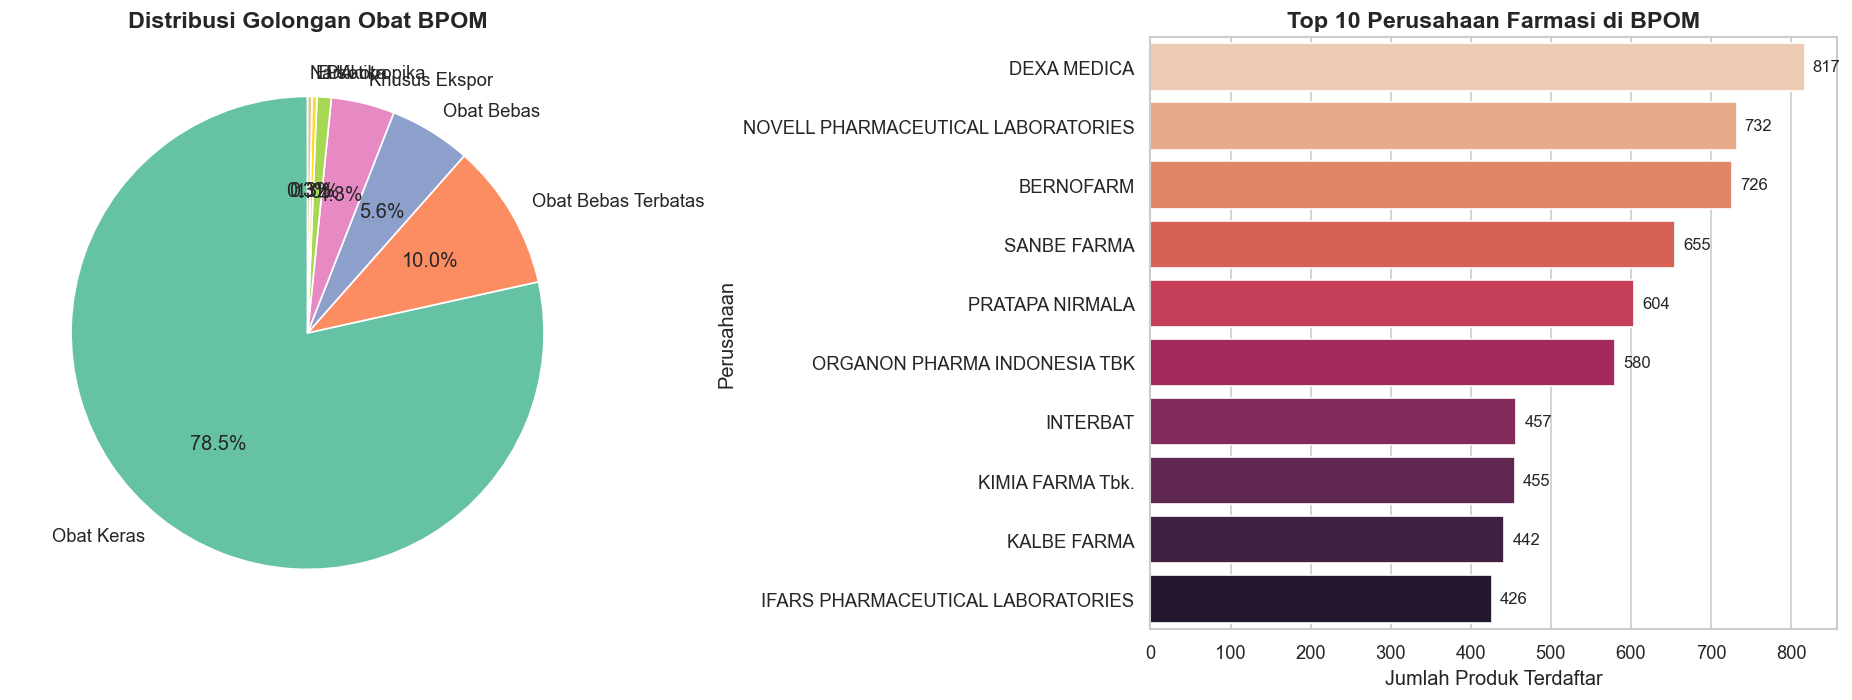

C:\Users\risky\AppData\Local\Temp\ipykernel_23496\3679128630.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sediaan.values, y=top_sediaan.index, palette="mako_r", ax=ax)


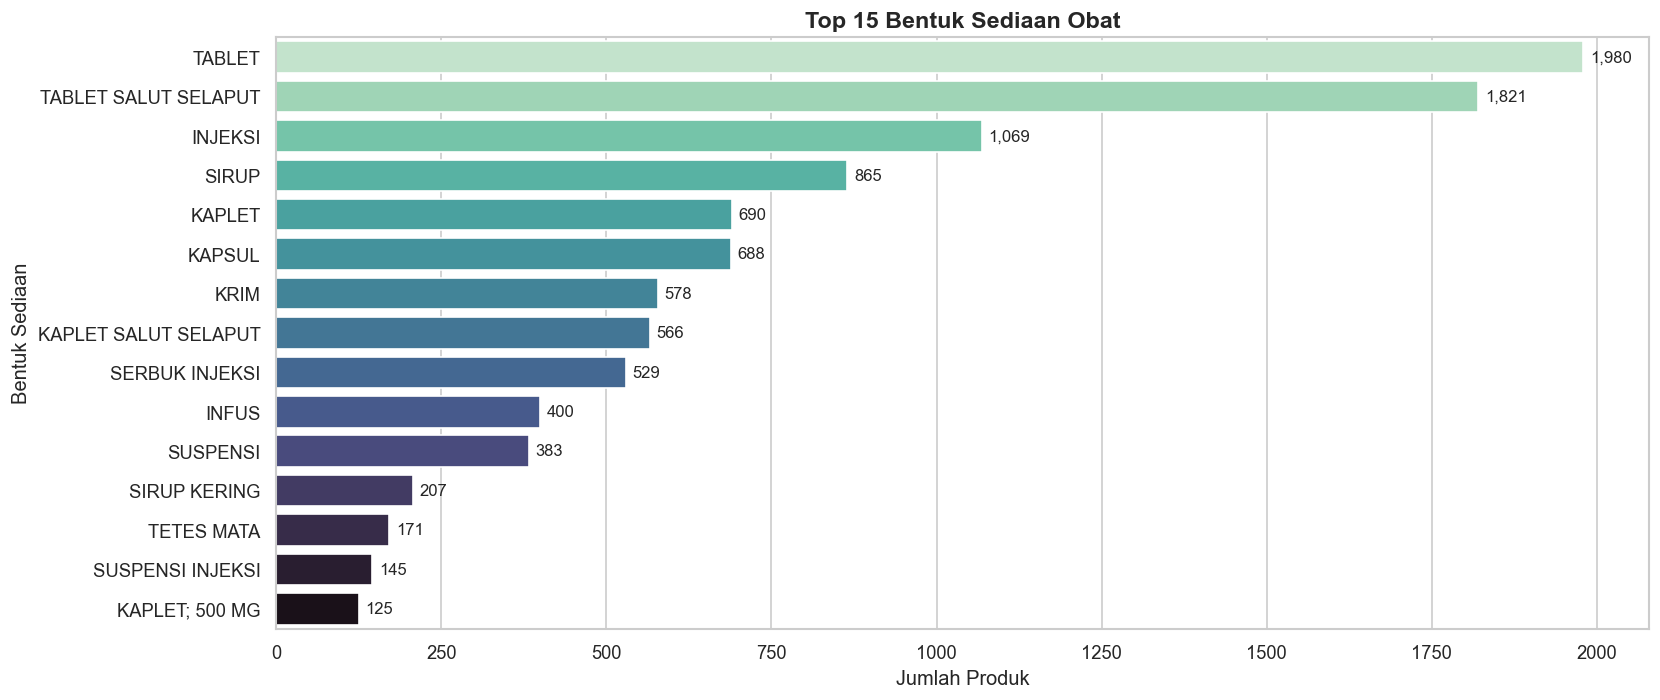

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart golongan
golongan_counts = obat_bpom['Golongan_Obat'].value_counts()
colors_pie = sns.color_palette("Set2", len(golongan_counts))
axes[0].pie(golongan_counts.values, labels=golongan_counts.index, autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[0].set_title('Distribusi Golongan Obat BPOM', fontsize=14, fontweight='bold')

# Bar chart Top 10 Perusahaan
top_perusahaan = obat_bpom['Perusahaan'].value_counts().head(10)
sns.barplot(x=top_perusahaan.values, y=top_perusahaan.index, ax=axes[1], palette="rocket_r")
axes[1].set_xlabel('Jumlah Produk Terdaftar')
axes[1].set_title('Top 10 Perusahaan Farmasi di BPOM', fontsize=14, fontweight='bold')
for i, v in enumerate(top_perusahaan.values):
    axes[1].text(v + 10, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
top_sediaan = obat_bpom['Bentuk Sediaan'].value_counts().head(15)
sns.barplot(x=top_sediaan.values, y=top_sediaan.index, palette="mako_r", ax=ax)
ax.set_xlabel('Jumlah Produk')
ax.set_title('Top 15 Bentuk Sediaan Obat', fontsize=14, fontweight='bold')
for i, v in enumerate(top_sediaan.values):
    ax.text(v + 10, i, f'{v:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()


### 9.3 Distribusi Kategori Makronutrien 61 Kelas


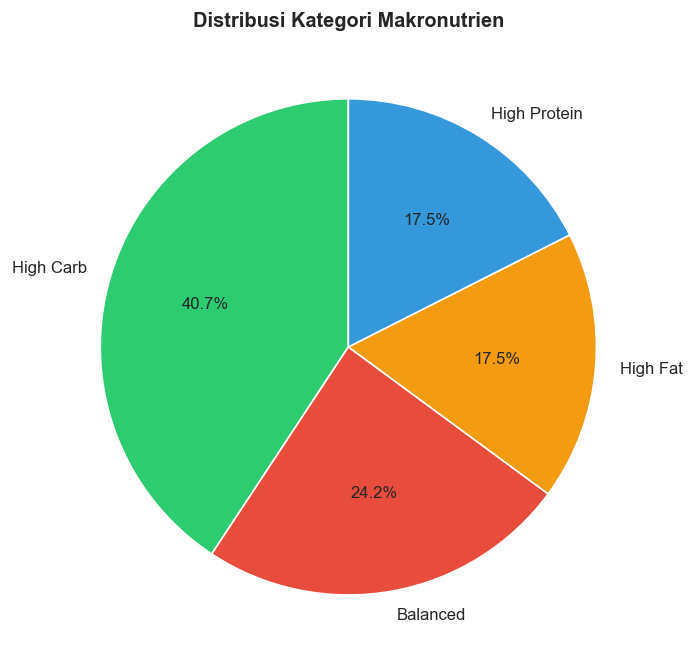

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))
macro_counts = unified_nutrition['macro_category'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#95a5a6']
macro_counts.plot(kind='pie', ax=ax, autopct='%1.1f%%', colors=colors[:len(macro_counts)],
                  startangle=90, textprops={'fontsize': 10})
ax.set_title('Distribusi Kategori Makronutrien', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'docs' / 'eda_macro_category.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Export Artefak Final


In [ ]:
# 1. Simpan unified nutrition 61 kelas
unified_nutrition.to_csv(OUTPUT_DIR / 'processed' / 'unified_nutrition.csv', index=False)
print(f"unified_nutrition.csv: {len(unified_nutrition)} baris")

# 2. Simpan mapping 61 kelas
mapping_df.to_csv(OUTPUT_DIR / 'processed' / 'mapping_image_nutrition.csv', index=False)
print(f"mapping_image_nutrition.csv: {len(mapping_df)} baris")

# 3. Simpan knowledge base
master_kb = {
    "metadata": {
        "version": "1.1-nutrition1-61-classes",
        "nutrition_source": "nutrition1.csv + manual curated imputation",
        "target_food_classes": len(target_food_classes),
        "indonesian_classes_covered": len(local_knowledge_base)
    },
    "local_ingredient_safety_registry": local_knowledge_base
}

with open(OUTPUT_DIR / 'for_backend' / 'drug_food_kb_final.json', 'w') as file_handle:
    json.dump(master_kb, file_handle, indent=2)
print(f"drug_food_kb_final.json: {len(local_knowledge_base)} obat lokal")

# 4. Generate classes.yaml dari 61 kelas target
import yaml
yolo_classes = target_food_classes

classes_yaml = {
    'path': '../datasets',
    'train': 'images/train', 'val': 'images/val', 'test': 'images/test',
    'nc': len(yolo_classes), 'names': yolo_classes
}

with open(OUTPUT_DIR / 'for_ai_engineer' / 'classes.yaml', 'w') as file_handle:
    yaml.dump(classes_yaml, file_handle, default_flow_style=False, sort_keys=False)
print(f"classes.yaml: {len(yolo_classes)} kelas")


---
## 11. Kesimpulan dan Rekomendasi

### Kesimpulan per Pertanyaan Bisnis

**Q1: Profil Nutrisi 61 Kelas Target**  
Profil nutrisi kini difokuskan pada 61 kelas makanan target. Sumber utama lookup adalah `nutrition1.csv`, dengan imputasi manual hanya untuk kelas yang tidak tersedia langsung.

**Q2: Distribusi Severity Interaksi Obat-Makanan**  
Dari dataset interaksi obat-makanan, mayoritas interaksi terklasifikasi sebagai MONITOR dan INTAKE_TIMING. Interaksi level AVOID_CRITICAL tetap menjadi prioritas utama sistem alert.

**Q3: Kelengkapan Data Nutrisi untuk 61 Kelas Target**  
Seluruh 61 kelas target sudah memiliki mapping nutrisi terverifikasi. Output final `unified_nutrition.csv` hanya berisi 61 baris, satu baris per kelas makanan.

**Q4: Kesiapan Dataset untuk AI Engineer**  
File konfigurasi (`classes.yaml`), database nutrisi 61 kelas (`unified_nutrition.csv`), mapping lookup (`mapping_image_nutrition.csv`), dan knowledge base (`drug_food_kb_final.json`) siap digunakan.

### Rekomendasi

1. **Training AI**: Gunakan `classes.yaml` yang berisi 61 kelas target agar konsisten dengan mapping nutrisi.
2. **Backend Lookup**: Gunakan `mapping_image_nutrition.csv` untuk menghubungkan output YOLO ke baris nutrisi final.
3. **Monitoring Data**: Jika kelas baru ditambahkan, update `61_kelas_resep_cleaned.csv`, `CLASS_TO_NUTRITION_61`, dan imputasi manual bila tidak ada di `nutrition1.csv`.
4. **Validasi Nutrisi**: Nilai manual sebaiknya ditinjau berkala dengan referensi TKPI/panganku.org atau sumber gizi resmi lain.
